# Q1 — Pretrained models (ResNet18, DenseNet121, VGG19)

Train 15-class classifiers using pretrained backbones. Compute per-class precision and recall.
Adjust hyperparameters and run on GPU if available.

In [1]:
# Setup for Colab and local environments
import os, sys
from pathlib import Path

# Detect if running in Colab
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print('Running in Google Colab')
    # Clone repo to get dataset
    os.system('git clone https://github.com/nelsunnel/LLMs-and-GenAI-Assignment.git /content/project')
    os.chdir('/content/project')
    # Install requirements
    os.system('pip install -q -r requirements.txt')
    PROJECT_ROOT = Path('/content/project')
else:
    print('Running locally')
    PROJECT_ROOT = Path('.')

print('Project root:', PROJECT_ROOT)

Running locally
Project root: .


In [2]:
# Imports and dataset discovery
import os, re, math, random, time
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from sklearn.metrics import precision_recall_fscore_support
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

# Set dataset root (uses PROJECT_ROOT from setup cell)
DATA_ROOT = PROJECT_ROOT / 'Datasets' / 'dataset'
print('DATA_ROOT:', DATA_ROOT)
# If dataset is structured as class subfolders, list classes
if DATA_ROOT.exists() and any(p.is_dir() for p in DATA_ROOT.iterdir()):
    CLASSES = sorted([p.name for p in DATA_ROOT.iterdir() if p.is_dir()])
else:
    raise RuntimeError('Cannot find dataset folders under Datasets/dataset')
NUM_CLASSES = len(CLASSES)
print('Found classes:', NUM_CLASSES)

DATA_ROOT: Datasets\dataset
Found classes: 15


In [3]:
# Utility: build train/test split per instructions (0001-0040 -> train; remaining -> test)
def build_splits(root, classes):
    train_list = []
    test_list = []
    num_re = re.compile(r'(\d+)')
    for class_idx, class_name in enumerate(classes):
        class_dir = root / class_name
        for p in class_dir.iterdir():
            if p.suffix.lower() not in ['.jpg', '.jpeg', '.png']:
                continue
            match = num_re.search(p.stem)
            if match and (1 <= int(match.group(1)) <= 40):
                train_list.append((str(p), class_idx))
            else:
                test_list.append((str(p), class_idx))
    return train_list, test_list

train_items, test_items = build_splits(DATA_ROOT, CLASSES)
print(f'Train items: {len(train_items)}, Test items: {len(test_items)}')

Train items: 600, Test items: 205


In [11]:
# PyTorch Dataset and DataLoaders
import platform

class SimpleImageDataset(Dataset):
    def __init__(self, items, transform=None):
        self.items = items
        self.transform = transform

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        path, label = self.items[idx]
        img = Image.open(path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label

IMG_SIZE = 224
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_ds = SimpleImageDataset(train_items, transform=train_transform)
test_ds = SimpleImageDataset(test_items, transform=test_transform)

# Windows multiprocessing in notebooks is fragile; use single-worker to avoid crashes.
if IN_COLAB:
    num_workers = 2
elif platform.system() == 'Windows':
    num_workers = 0
else:
    num_workers = 4

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=num_workers)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=num_workers)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


In [12]:
# Model factory
def make_model(name, num_classes, pretrained=True):
    if name == 'resnet18':
        model = models.resnet18(pretrained=pretrained)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif name == 'densenet121':
        model = models.densenet121(pretrained=pretrained)
        model.classifier = nn.Linear(model.classifier.in_features, num_classes)
    elif name == 'vgg19':
        model = models.vgg19(pretrained=pretrained)
        model.classifier[6] = nn.Linear(model.classifier[6].in_features, num_classes)
    else:
        raise ValueError(f'Unknown model name: {name}')
    return model.to(device)

In [13]:
# Training loop
def train_model(model, loader, criterion, optimizer, epochs=3):
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        pbar = tqdm(loader, desc=f'Epoch {epoch+1}/{epochs}')
        for inputs, labels in pbar:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            pbar.set_postfix({'loss': running_loss / (pbar.n + 1)})
    print('Finished Training')

In [14]:
# Evaluation loop
def evaluate(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc='Evaluating'):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return np.array(all_labels), np.array(all_preds)

In [15]:
# Main function to run experiment and report metrics
def run_and_report(model_name, epochs=3):
    print(f'--- Running experiment for {model_name} ---')
    model = make_model(model_name, NUM_CLASSES)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    start_time = time.time()
    train_model(model, train_loader, criterion, optimizer, epochs=epochs)
    print(f'Training took {time.time() - start_time:.2f}s')

    y_true, y_pred = evaluate(model, test_loader)
    
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, average=None, labels=list(range(NUM_CLASSES))
    )
    
    report_df = pd.DataFrame({
        'class': CLASSES,
        'precision': precision,
        'recall': recall,
        'f1-score': f1,
        'support': support
    })
    
    print(f'\nResults for {model_name}:')
    print(report_df)
    return report_df

In [16]:
# Run for ResNet18
resnet_results = run_and_report('resnet18', epochs=3)

--- Running experiment for resnet18 ---


Epoch 1/3:   0%|          | 0/19 [00:00<?, ?it/s]

Epoch 2/3:   0%|          | 0/19 [00:00<?, ?it/s]

Epoch 3/3:   0%|          | 0/19 [00:00<?, ?it/s]

Finished Training
Training took 17.04s


Evaluating:   0%|          | 0/7 [00:00<?, ?it/s]


Results for resnet18:
             class  precision    recall  f1-score  support
0        accordion   1.000000  0.600000  0.750000       15
1             bass   0.437500  1.000000  0.608696       14
2           camera   0.769231  1.000000  0.869565       10
3        crocodile   0.428571  0.900000  0.580645       10
4   crocodile_head   0.666667  0.363636  0.470588       11
5              cup   0.857143  0.705882  0.774194       17
6      dollar_bill   0.666667  1.000000  0.800000       12
7              emu   0.750000  0.692308  0.720000       13
8       gramophone   0.500000  0.818182  0.620690       11
9         hedgehog   0.857143  0.428571  0.571429       14
10        nautilus   1.000000  0.800000  0.888889       15
11           pizza   1.000000  0.923077  0.960000       13
12         pyramid   1.000000  0.647059  0.785714       17
13       sea_horse   1.000000  0.058824  0.111111       17
14   windsor_chair   0.842105  1.000000  0.914286       16


In [17]:
# Run for DenseNet121
densenet_results = run_and_report('densenet121', epochs=3)

--- Running experiment for densenet121 ---


c:\Users\undha\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\undha\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to C:\Users\undha/.cache\torch\hub\checkpoints\densenet121-a639ec97.pth
100%|██████████| 30.8M/30.8M [00:29<00:00, 1.11MB/s]


Epoch 1/3:   0%|          | 0/19 [00:00<?, ?it/s]

Epoch 2/3:   0%|          | 0/19 [00:00<?, ?it/s]

Epoch 3/3:   0%|          | 0/19 [00:00<?, ?it/s]

Finished Training
Training took 24.96s


Evaluating:   0%|          | 0/7 [00:00<?, ?it/s]


Results for densenet121:
             class  precision    recall  f1-score  support
0        accordion   1.000000  1.000000  1.000000       15
1             bass   0.764706  0.928571  0.838710       14
2           camera   1.000000  0.800000  0.888889       10
3        crocodile   1.000000  0.100000  0.181818       10
4   crocodile_head   0.625000  0.909091  0.740741       11
5              cup   0.928571  0.764706  0.838710       17
6      dollar_bill   0.923077  1.000000  0.960000       12
7              emu   0.571429  0.923077  0.705882       13
8       gramophone   1.000000  0.727273  0.842105       11
9         hedgehog   0.866667  0.928571  0.896552       14
10        nautilus   0.789474  1.000000  0.882353       15
11           pizza   1.000000  0.846154  0.916667       13
12         pyramid   1.000000  0.823529  0.903226       17
13       sea_horse   1.000000  0.529412  0.692308       17
14   windsor_chair   0.666667  1.000000  0.800000       16


In [18]:
# Run for VGG19
vgg_results = run_and_report('vgg19', epochs=3)

--- Running experiment for vgg19 ---


c:\Users\undha\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\undha\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to C:\Users\undha/.cache\torch\hub\checkpoints\vgg19-dcbb9e9d.pth
100%|██████████| 548M/548M [06:48<00:00, 1.41MB/s]  


Epoch 1/3:   0%|          | 0/19 [00:00<?, ?it/s]

Epoch 2/3:   0%|          | 0/19 [00:00<?, ?it/s]

Epoch 3/3:   0%|          | 0/19 [00:00<?, ?it/s]

Finished Training
Training took 314.49s


Evaluating:   0%|          | 0/7 [00:00<?, ?it/s]


Results for vgg19:
             class  precision  recall  f1-score  support
0        accordion   0.131579     1.0  0.232558       15
1             bass   0.000000     0.0  0.000000       14
2           camera   0.021978     0.2  0.039604       10
3        crocodile   0.000000     0.0  0.000000       10
4   crocodile_head   0.000000     0.0  0.000000       11
5              cup   0.000000     0.0  0.000000       17
6      dollar_bill   0.000000     0.0  0.000000       12
7              emu   0.000000     0.0  0.000000       13
8       gramophone   0.000000     0.0  0.000000       11
9         hedgehog   0.000000     0.0  0.000000       14
10        nautilus   0.000000     0.0  0.000000       15
11           pizza   0.000000     0.0  0.000000       13
12         pyramid   0.000000     0.0  0.000000       17
13       sea_horse   0.000000     0.0  0.000000       17
14   windsor_chair   0.000000     0.0  0.000000       16


c:\Users\undha\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## Visualizations

The following cell generates a series of comprehensive visualizations to compare the performance metrics (Precision, Recall, F1-Score) across our three evaluated architectures: **ResNet18**, **DenseNet121**, and **VGG19**.

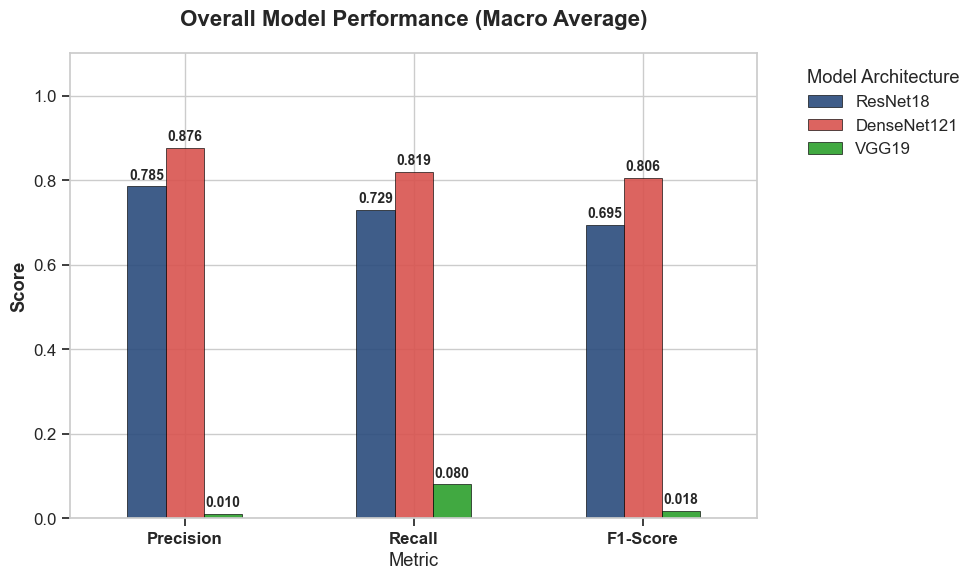

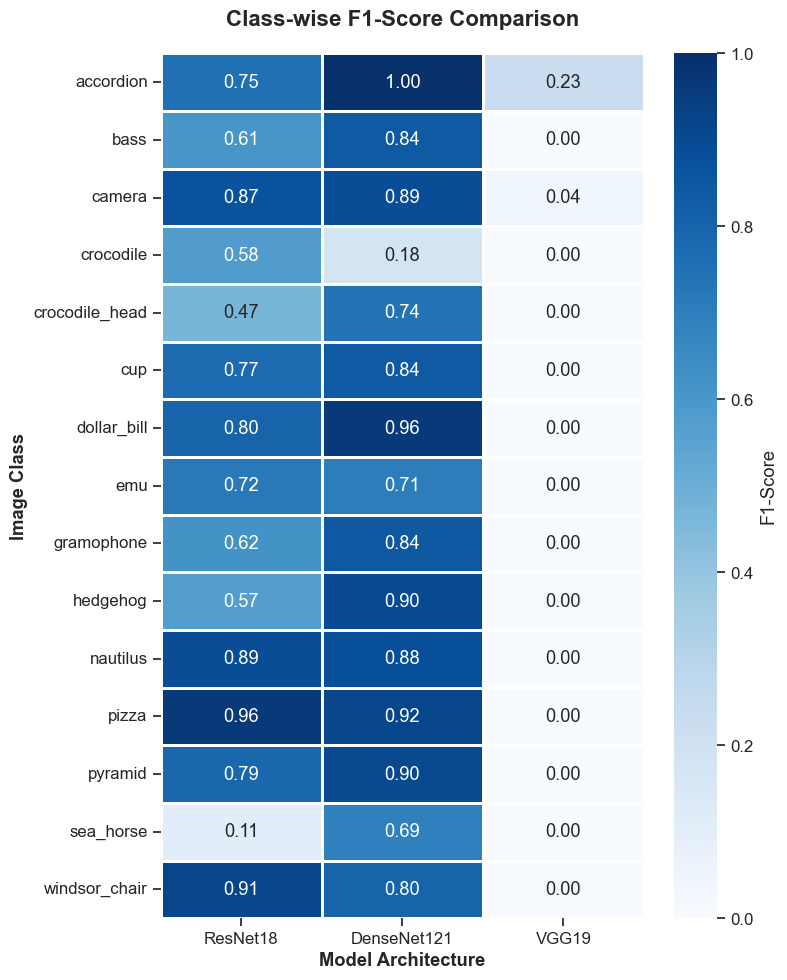

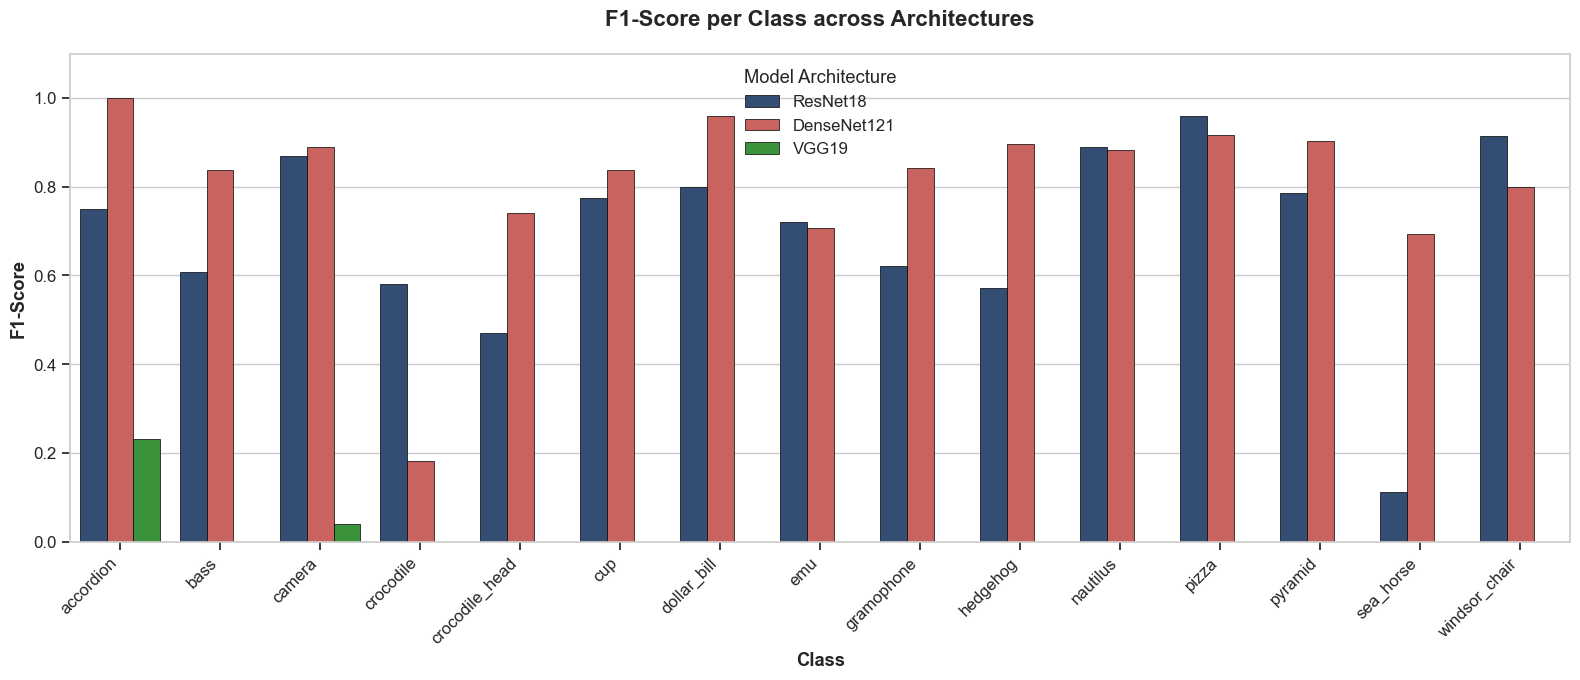

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Set a clean, professional consulting-style aesthetic
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook", font_scale=1.1)
colors = ['#2A4B7C', '#D9534F', '#2CA02C'] # Professional navy, warm red, muted green

def prepare_visualizations(resnet_df, densenet_df, vgg_df):
    """
    Generate comprehensive, consulting-style visualizations. 
    Assumes each df has columns: 'class', 'precision', 'recall', 'f1-score', 'support'
    """
    # 1. Combine Data
    combined_f1 = pd.DataFrame({
        'Class': resnet_df['class'],
        'ResNet18': resnet_df['f1-score'],
        'DenseNet121': densenet_df['f1-score'],
        'VGG19': vgg_df['f1-score']
    }).set_index('Class')

    # Calculate Macro Averages
    macro_avgs = pd.DataFrame({
        'Metric': ['Precision', 'Recall', 'F1-Score'],
        'ResNet18': [resnet_df['precision'].mean(), resnet_df['recall'].mean(), resnet_df['f1-score'].mean()],
        'DenseNet121': [densenet_df['precision'].mean(), densenet_df['recall'].mean(), densenet_df['f1-score'].mean()],
        'VGG19': [vgg_df['precision'].mean(), vgg_df['recall'].mean(), vgg_df['f1-score'].mean()]
    }).set_index('Metric')

    # --- Plot 1: Overall Macro-Average Performance ---
    fig, ax = plt.subplots(figsize=(10, 6))
    macro_avgs.plot(kind='bar', ax=ax, color=colors, alpha=0.9, edgecolor='black', linewidth=0.5)
    
    plt.title('Overall Model Performance (Macro Average)', pad=20, fontweight='bold', fontsize=16)
    plt.ylabel('Score', fontweight='bold')
    plt.ylim(0, 1.1)
    plt.xticks(rotation=0, fontweight='bold')
    plt.legend(title='Model Architecture', bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # Add value annotations on bars
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', padding=3, fontweight='bold', fontsize=10)
    plt.tight_layout()
    plt.show()

    # --- Plot 2: Class-wise F1-Score Heatmap ---
    plt.figure(figsize=(8, 10))
    sns.heatmap(combined_f1, annot=True, cmap='Blues', fmt=".2f", 
                linewidths=1, linecolor='white', vmin=0, vmax=1, cbar_kws={'label': 'F1-Score'})
    plt.title('Class-wise F1-Score Comparison', pad=20, fontweight='bold', fontsize=16)
    plt.ylabel('Image Class', fontweight='bold')
    plt.xlabel('Model Architecture', fontweight='bold')
    plt.tight_layout()
    plt.show()

    # --- Plot 3: Detailed Class-wise Bar Chart ---
    f1_melted = combined_f1.reset_index().melt(id_vars='Class', var_name='Model', value_name='F1-Score')
    
    plt.figure(figsize=(16, 7))
    sns.barplot(data=f1_melted, x='Class', y='F1-Score', hue='Model', palette=colors, edgecolor='black', linewidth=0.5)
    
    plt.title('F1-Score per Class across Architectures', pad=20, fontweight='bold', fontsize=16)
    plt.ylabel('F1-Score', fontweight='bold')
    plt.xlabel('Class', fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.ylim(0, 1.1)
    plt.legend(title='Model Architecture')
    
    plt.tight_layout()
    plt.show()

# Execute plot generation if the baseline variables exist
try:
    prepare_visualizations(resnet_results, densenet_results, vgg_results)
except NameError:
    print("Metrics dataframes are not defined. Please ensure ResNet, DenseNet, and VGG cells have been executed.")